# Linear Regression on Real estate

In [2]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Real estate.csv')

In [4]:
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.drop('No', axis=1, inplace=True)

In [8]:
df.columns

Index(['X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')

<Axes: xlabel='X1 transaction date'>

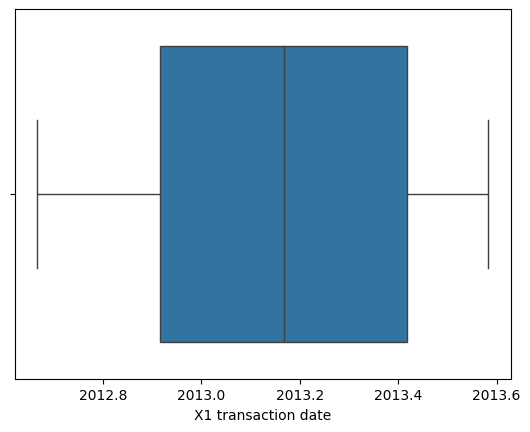

In [9]:
sns.boxplot(df,x='X1 transaction date')

<Axes: xlabel='X2 house age'>

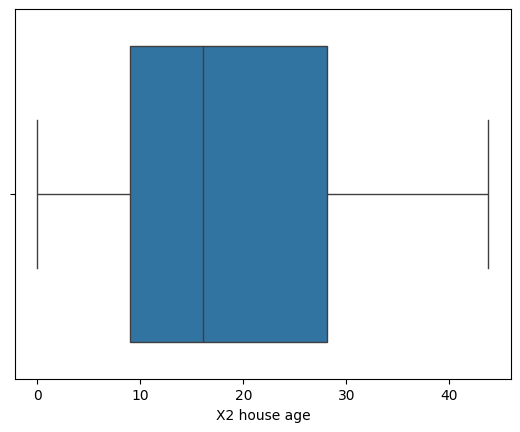

In [10]:
sns.boxplot(df,x='X2 house age')

<Axes: xlabel='X3 distance to the nearest MRT station'>

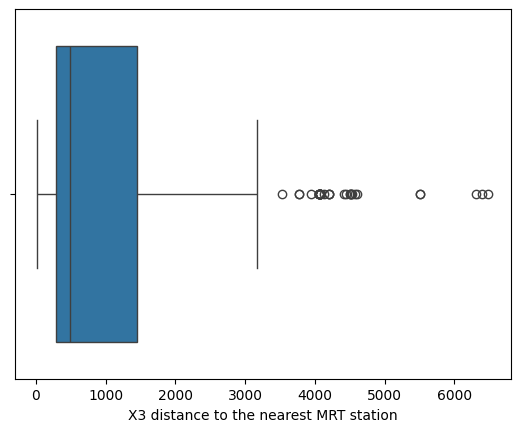

In [11]:
sns.boxplot(df,x='X3 distance to the nearest MRT station')

<Axes: xlabel='X4 number of convenience stores'>

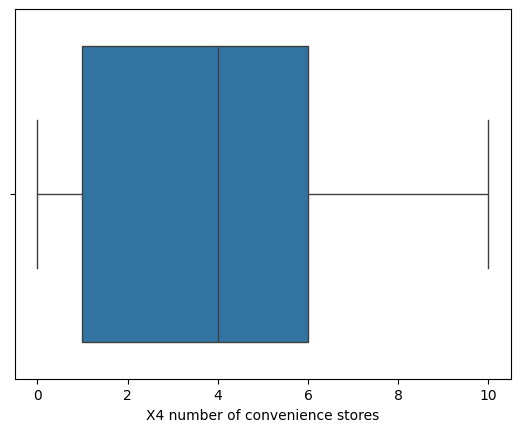

In [12]:
sns.boxplot(df,x='X4 number of convenience stores')

<Axes: xlabel='X5 latitude'>

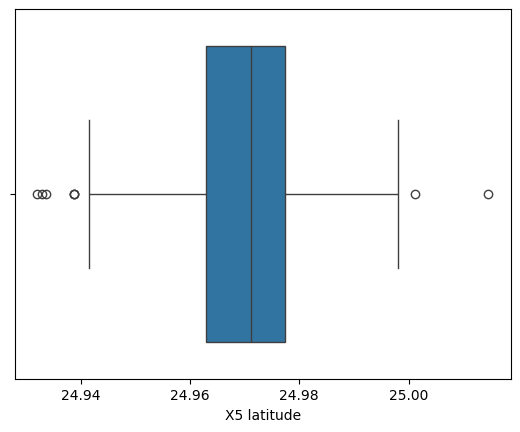

In [13]:
sns.boxplot(df,x='X5 latitude')

<Axes: xlabel='X6 longitude'>

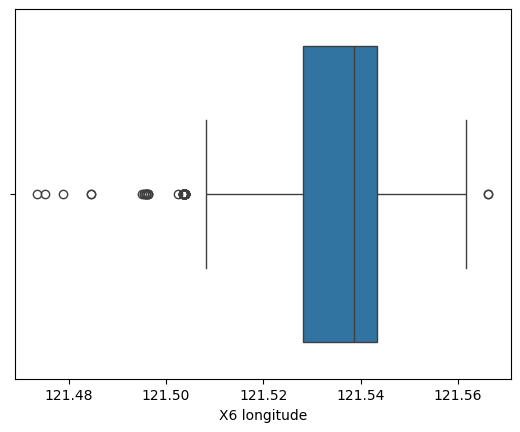

In [14]:
sns.boxplot(df,x='X6 longitude')

<Axes: xlabel='Y house price of unit area'>

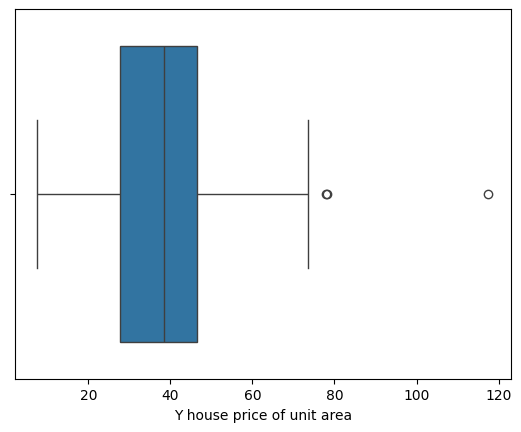

In [15]:
sns.boxplot(df,x='Y house price of unit area')

There are four columns with outliers
- `X3 distance to the nearest MRT station`
- `X5 latitude`
- `X6 longitude`
- `Y house price of unit area`

In [16]:
q1 = df['X3 distance to the nearest MRT station'].quantile(0.25)
q3 = df['X3 distance to the nearest MRT station'].quantile(0.75)

IQR = q3 - q1

lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

df = df[(df['X3 distance to the nearest MRT station'] >= lower_bound) & (df['X3 distance to the nearest MRT station'] <= upper_bound)] 

<Axes: xlabel='X3 distance to the nearest MRT station'>

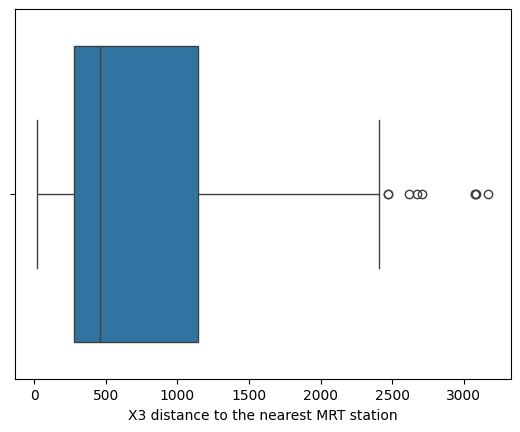

In [17]:
sns.boxplot(df,x='X3 distance to the nearest MRT station')

Lets check its distribution

<Axes: xlabel='X3 distance to the nearest MRT station', ylabel='Count'>

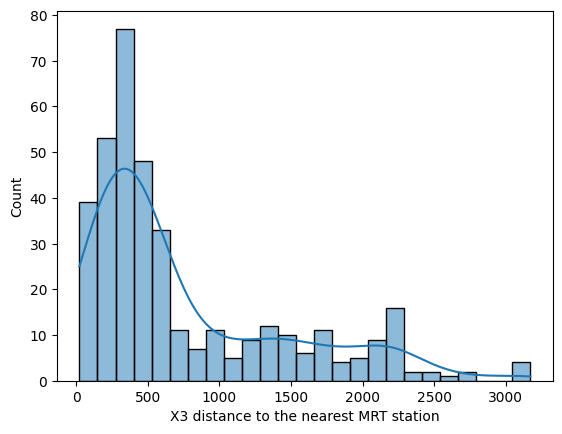

In [18]:
sns.histplot(df,x='X3 distance to the nearest MRT station', bins=25, kde=True)

The distribution is right skew we can apply log transformation to compress the points

In [19]:
import numpy as np
df['X3 distance to the nearest MRT station'] = np.log(df['X3 distance to the nearest MRT station'])  # it is used to compress the very high values

<Axes: xlabel='X3 distance to the nearest MRT station', ylabel='Count'>

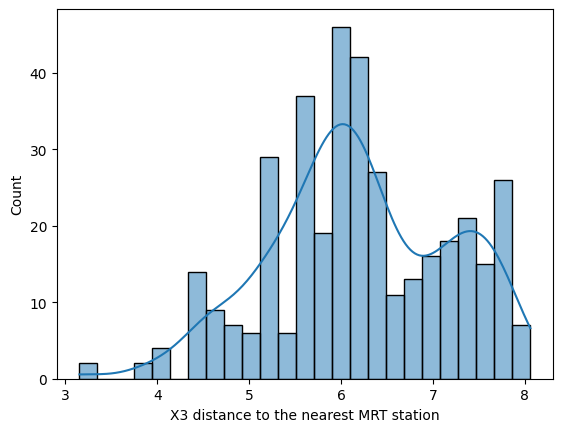

In [20]:
sns.histplot(df,x='X3 distance to the nearest MRT station', bins=25, kde=True)

Still non-normal distribution but slightly better than before

<Axes: xlabel='X3 distance to the nearest MRT station'>

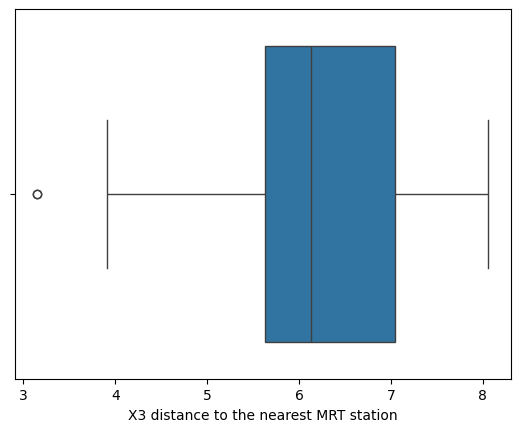

In [21]:
sns.boxplot(df,x='X3 distance to the nearest MRT station')

Most of the outliers are removed\
lets remove for `X5 latitude`

In [22]:
q1 = df['X5 latitude'].quantile(0.25)
q3 = df['X5 latitude'].quantile(0.75)

IQR = q3 - q1

lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

df = df[(df['X5 latitude'] >= lower_bound) & (df['X5 latitude'] <= upper_bound)] 

<Axes: xlabel='X5 latitude'>

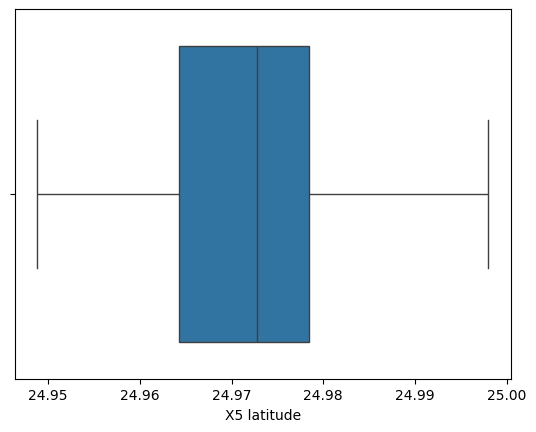

In [23]:
sns.boxplot(df,x='X5 latitude')

The outliers are successfully removed for `X5 latitude` column
Now we will remove for `X6 longitude`

In [24]:
q1 = df['X6 longitude'].quantile(0.25)
q3 = df['X6 longitude'].quantile(0.75)

IQR = q3 - q1

lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

df = df[(df['X6 longitude'] >= lower_bound) & (df['X6 longitude'] <= upper_bound)] 

<Axes: xlabel='X6 longitude'>

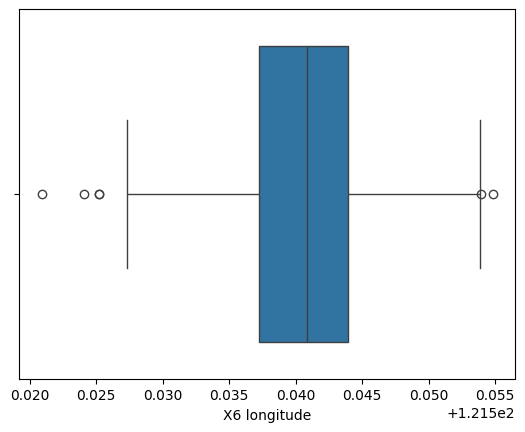

In [25]:
sns.boxplot(df,x='X6 longitude')

In [26]:
q1 = df['X3 distance to the nearest MRT station'].quantile(0.25)
q3 = df['X3 distance to the nearest MRT station'].quantile(0.75)

IQR = q3 - q1

lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

df = df[(df['X3 distance to the nearest MRT station'] >= lower_bound) & (df['X3 distance to the nearest MRT station'] <= upper_bound)] 

<Axes: xlabel='X3 distance to the nearest MRT station'>

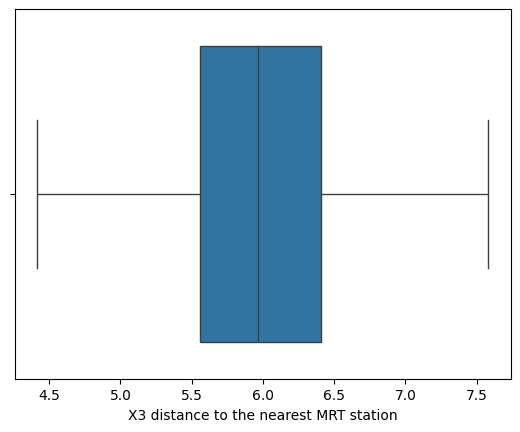

In [27]:
sns.boxplot(df,x='X3 distance to the nearest MRT station')

In [29]:
df.corr()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
X1 transaction date,1.000000,0.004346,0.077735,0.053935,0.034088,0.072649,0.141667
X2 house age,0.004346,1.000000,0.107654,0.068547,0.029559,-0.100439,-0.285627
X3 distance to the nearest MRT station,0.077735,0.107654,1.000000,-0.573196,-0.192453,0.036124,-0.551475
X4 number of convenience stores,0.053935,0.068547,-0.573196,1.000000,0.313838,0.240354,0.412593
X5 latitude,0.034088,0.029559,-0.192453,0.313838,1.000000,-0.206895,0.417718
X6 longitude,0.072649,-0.100439,0.036124,0.240354,-0.206895,1.000000,0.021223
Y house price of unit area,0.141667,-0.285627,-0.551475,0.412593,0.417718,0.021223,1.000000


In [28]:
df.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,2012.917,32.0,4.441225,10,24.98298,121.54024,37.9
1,2012.917,19.5,5.725527,9,24.98034,121.53951,42.2
2,2013.583,13.3,6.331474,5,24.98746,121.54391,47.3
3,2013.500,13.3,6.331474,5,24.98746,121.54391,54.8
4,2012.833,5.0,5.967603,5,24.97937,121.54245,43.1


In [31]:
X = df.drop('Y house price of unit area', axis = 1)
y = df[['Y house price of unit area']]

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=42)

In [33]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [34]:
model.coef_

array([[ 7.56513204e+00, -2.53413177e-01, -7.52280568e+00,
        -1.98513958e-03,  4.49852323e+02,  1.44945675e+02]])

In [35]:
model.intercept_

array([-43988.58857545])

In [36]:
y_pred_train = model.predict(X_train)

In [37]:
from sklearn.metrics import mean_squared_error,r2_score

In [38]:
mean_squared_error(y_train,y_pred_train)

81.06240851744343

In [39]:
r2_score(y_train,y_pred_train)

0.4747735328962749

In [40]:
y_pred_test= model.predict(X_test)

In [41]:
mean_squared_error(y_test,y_pred_test)

39.713973394346915

In [42]:
r2_score(y_test,y_pred_test)

0.6104306902417924